In [1]:
# NWIS - Exploratory Data Analysis
# Nearby Wells Intelligence System

# Purpose:
# Understand drilling behaviour and identify useful patterns
# before training ML models for drilling-risk prediction.

# Risks covered:
# Mud Loss, Stuck Pipe, Overpressure,
# Torque Spike, Cementing Issue and Kick

# Mud Loss – Drilling fluid disappears into the rock instead of circulating back up. 
# Like pouring water into a leaky bucket — you lose pressure control and it gets expensive fast.

# Stuck Pipe – The drill string gets physically stuck downhole and won't move up, down, or rotate.
# Think of a shovel jammed in wet clay — you can't pull it out or push it further.

# Overpressure – The rock formation is holding fluid/gas at pressure higher than expected, pushing back against the well.
# If your mud weight isn't enough to counter it, things can blow back at you.

# Torque Spike – A sudden jump in the rotational force needed to turn the drill string,
# usually a warning sign of friction, a tight hole, or something obstructing the bit.

# Cementing Issue – Problems with the cement job that's supposed to seal the well casing
# to the rock — poor bonding, channeling, or incomplete coverage, which can compromise well integrity later.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load Dataset
FILE_PATH = "NWIS_drilling_data_updated.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

Dataset loaded successfully.
Rows    : 10,876
Columns : 35


In [5]:
# df.head()

,Well_ID,Timestamp,Depth_MD,Depth_TVD,Formation,ROP,WOB,RPM,Torque,Standpipe_Pressure,...,Previous_NPT_Count,Similar_Well_Risk_Count,Mud_Loss_Label,Stuck_Pipe_Label,Overpressure_Label,Torque_Spike_Label,Cementing_Issue_Label,Kick_Label,Risk_Severity,Recommended_Action
0,W001,2026-01-15 06:00:00,200.0,197.0,Alluvium_Top,14.45,46.31,119.1,276.5,340.9,...,8781,3,0,0,0,0,0,0,Low,Continue monitoring drilling parameters and of...
1,W001,2026-01-15 06:15:00,220.0,217.6,Alluvium_Top,14.95,47.23,120.7,269.7,338.1,...,8781,3,0,0,0,0,0,0,Low,Continue monitoring drilling parameters and of...
2,W001,2026-01-15 06:30:00,240.0,236.5,Alluvium_Top,15.28,48.78,120.5,263.6,342.4,...,8781,3,0,0,0,0,0,0,Low,Continue monitoring drilling parameters and of...
3,W001,2026-01-15 06:45:00,260.0,256.6,Alluvium_Top,14.16,49.33,119.4,263.7,350.6,...,8781,3,0,0,0,0,0,0,Low,Continue monitoring drilling parameters and of...
4,W001,2026-01-15 07:00:00,280.0,276.6,Alluvium_Top,14.90,49.86,121.6,268.6,344.3,...,8781,3,0,0,0,0,0,0,Low,Continue monitoring drilling parameters and of...


In [6]:
# df.tail()

,Well_ID,Timestamp,Depth_MD,Depth_TVD,Formation,ROP,WOB,RPM,Torque,Standpipe_Pressure,...,Previous_NPT_Count,Similar_Well_Risk_Count,Mud_Loss_Label,Stuck_Pipe_Label,Overpressure_Label,Torque_Spike_Label,Cementing_Issue_Label,Kick_Label,Risk_Severity,Recommended_Action
10871,W045,2026-03-04 23:30:00,2843.0,2805.17,Shale_B,9.101585,39.511162,84.133773,359.771465,463.884777,...,10717,7,1,0,1,0,1,1,High,"Review mud weight, flow rate and loss indicato..."
10872,W045,2026-03-04 23:45:00,2852.3,2823.58,Shale_B,7.213256,42.607641,82.962926,373.789632,454.001087,...,10717,8,0,1,1,1,1,0,High,"Review torque, WOB and ROP trends; compare wit..."
10873,W045,2026-03-05 00:00:00,2861.5,2830.79,Shale_B,12.877531,32.725045,94.734229,309.492071,455.725341,...,10717,7,0,0,1,0,1,1,Moderate,Review pore/reservoir pressure and mud-weight ...
10874,W045,2026-03-05 00:15:00,2870.8,2860.87,Shale_B,6.435804,40.177849,87.768043,383.250794,448.597016,...,10717,9,0,1,1,1,1,1,High,"Review torque, WOB and ROP trends; compare wit..."
10875,W045,2026-03-05 00:30:00,2880.0,2871.27,Shale_B,4.468757,40.747570,85.610006,384.272031,426.873653,...,10717,9,0,1,1,1,1,1,High,"Review torque, WOB and ROP trends; compare wit..."


In [4]:
df.shape

(10876, 35)

In [5]:
print("Columns :")
for i, column in enumerate(df.columns, 1):
    print(f"{i:2}. {column}")

Columns :
 1. Well_ID
 2. Timestamp
 3. Depth_MD
 4. Depth_TVD
 5. Formation
 6. ROP
 7. WOB
 8. RPM
 9. Torque
10. Standpipe_Pressure
11. Flow_Rate
12. Mud_Weight
13. Plastic_Viscosity
14. Yield_Point
15. Hook_Load
16. Inclination
17. Bit_Type
18. Reservoir_Pressure
19. Formation_Pore_Pressure
20. Distance_To_Nearest_Offset_m
21. Historical_Event_Count
22. Previous_Mud_Loss_Count
23. Previous_Stuck_Pipe_Count
24. Previous_Kick_Count
25. Previous_NPT_Count
26. Similar_Well_Risk_Count
27. Mud_Loss_Label
28. Stuck_Pipe_Label
29. Overpressure_Label
30. Torque_Spike_Label
31. Cementing_Issue_Label
32. Kick_Label
33. Fishing_Label
34. Risk_Severity
35. Recommended_Action


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10876 entries, 0 to 10875
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Well_ID                       10876 non-null  object 
 1   Timestamp                     10876 non-null  object 
 2   Depth_MD                      10876 non-null  float64
 3   Depth_TVD                     10876 non-null  float64
 4   Formation                     10876 non-null  object 
 5   ROP                           10876 non-null  float64
 6   WOB                           10876 non-null  float64
 7   RPM                           10876 non-null  float64
 8   Torque                        10876 non-null  float64
 9   Standpipe_Pressure            10876 non-null  float64
 10  Flow_Rate                     10876 non-null  float64
 11  Mud_Weight                    10876 non-null  float64
 12  Plastic_Viscosity             10876 non-null  float64
 13  Y

In [7]:
# Checking for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found.")
else:
    display(pd.DataFrame({
        "Missing_Values": missing,
        "Missing_Percentage": (missing / len(df) * 100).round(2)
    }))

No missing values found.


In [8]:
# Checking for duplicate values

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [9]:
df.describe()

,Depth_MD,Depth_TVD,ROP,WOB,RPM,Torque,Standpipe_Pressure,Flow_Rate,Mud_Weight,Plastic_Viscosity,...,Previous_Kick_Count,Previous_NPT_Count,Similar_Well_Risk_Count,Mud_Loss_Label,Stuck_Pipe_Label,Overpressure_Label,Torque_Spike_Label,Cementing_Issue_Label,Kick_Label,Fishing_Label
count,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,...,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000,10876.000000
mean,1631.371828,1617.407855,8.918787,46.972946,109.876755,374.880802,402.032347,890.138516,1.387881,24.675416,...,46.352152,18381.105645,8.019952,0.390033,0.420007,0.380011,0.409985,0.380011,0.399963,0.170007
std,832.056311,824.663003,5.912480,9.838726,13.870325,116.535576,71.543006,86.051236,0.072869,3.030914,...,52.994210,11538.546387,3.110836,0.487780,0.493582,0.485411,0.491853,0.485411,0.489913,0.375657
min,200.000000,195.000000,0.566040,19.471599,68.841360,150.000000,243.500000,645.500000,1.149562,17.516485,...,0.000000,1808.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,912.400000,905.092500,4.468399,40.589774,101.594512,285.691064,358.181783,834.459091,1.337720,22.720577,...,1.000000,7288.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1630.250000,1616.480000,7.239467,47.066352,110.261005,349.686810,390.401326,884.724752,1.392774,24.089706,...,26.000000,14190.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2346.725000,2328.312500,12.519889,53.955479,118.734750,418.415236,424.330058,945.618569,1.436733,26.403351,...,77.000000,27691.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,3280.000000,3241.970000,30.000000,65.000000,154.819996,700.000000,750.000000,1150.000000,1.600000,34.858369,...,226.000000,38096.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [38]:
# These groups separate the actual drilling measurements and ML prediction targets.

drilling_parameters = [
    "ROP",
    "WOB",
    "RPM",
    "Torque",
    "Standpipe_Pressure",
    "Flow_Rate",
    "Mud_Weight",
    "Plastic_Viscosity",
    "Yield_Point",
    "Hook_Load"
]

context_features = [
    "Depth_MD",
    "Depth_TVD",
    "Inclination",
    "Reservoir_Pressure",
    "Formation_Pore_Pressure",
    "Distance_To_Nearest_Offset_m",
    "Historical_Event_Count",
    "Similar_Well_Risk_Count",
    "Fishing_Label"
]

historical_features = [
    "Previous_Mud_Loss_Count",
    "Previous_Stuck_Pipe_Count",
    "Previous_Kick_Count",
    "Previous_NPT_Count"
]

risk_labels = [
    "Mud_Loss_Label",
    "Stuck_Pipe_Label",
    "Overpressure_Label",
    "Torque_Spike_Label",
    "Cementing_Issue_Label",
]

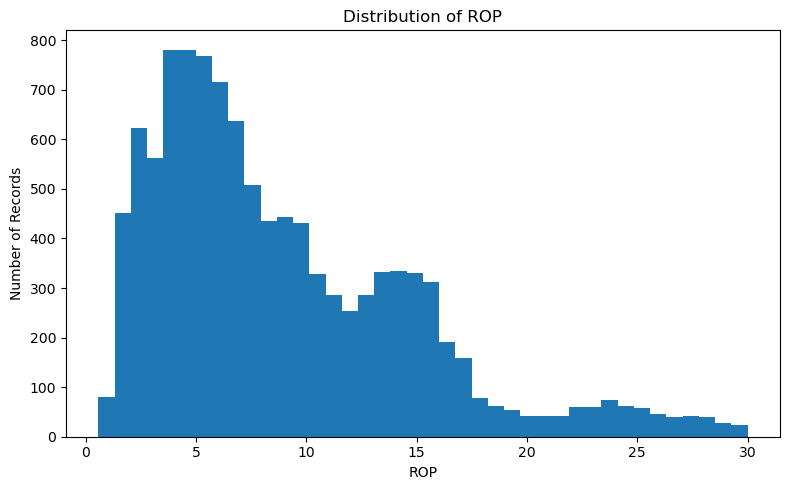

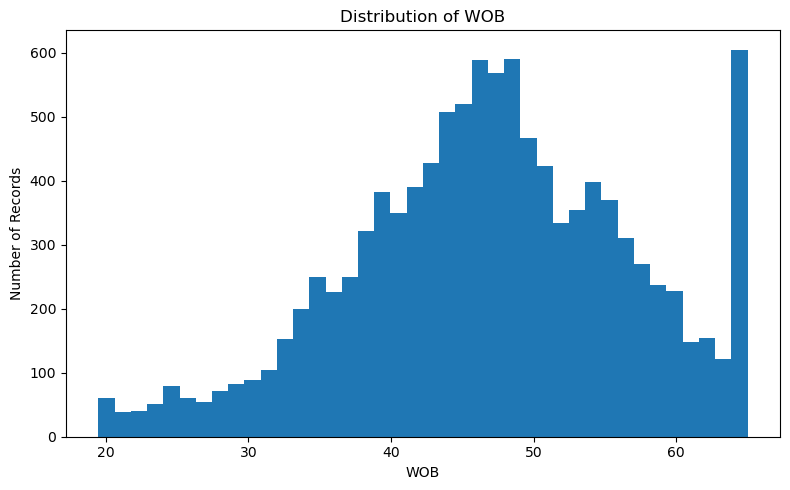

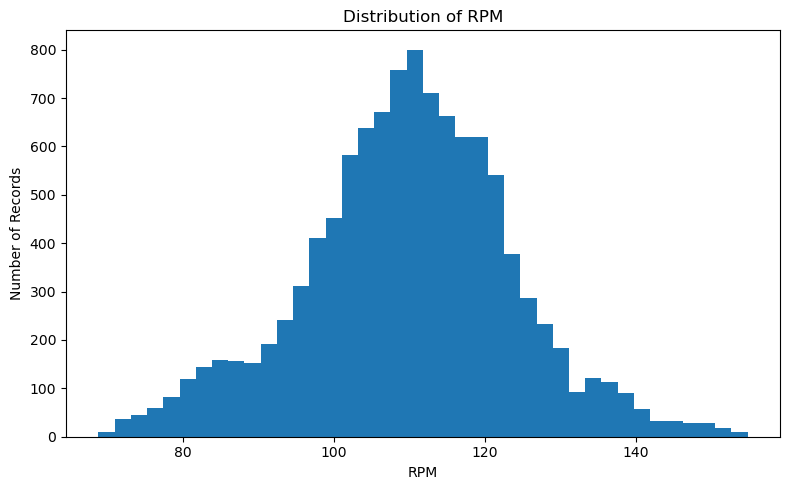

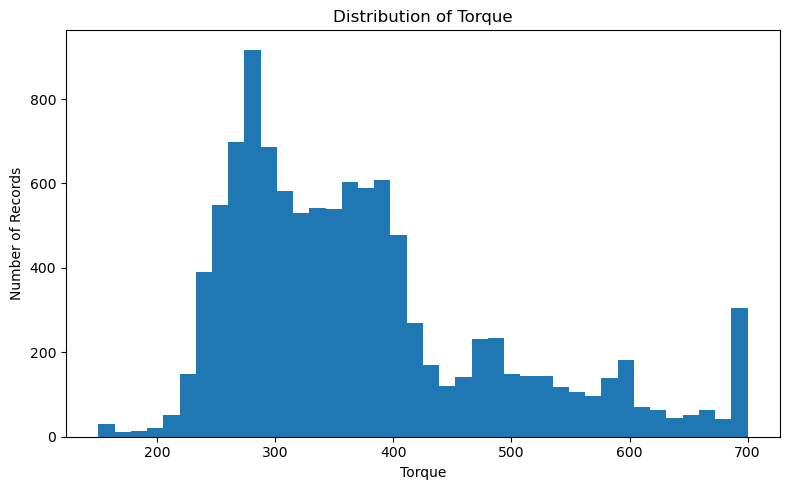

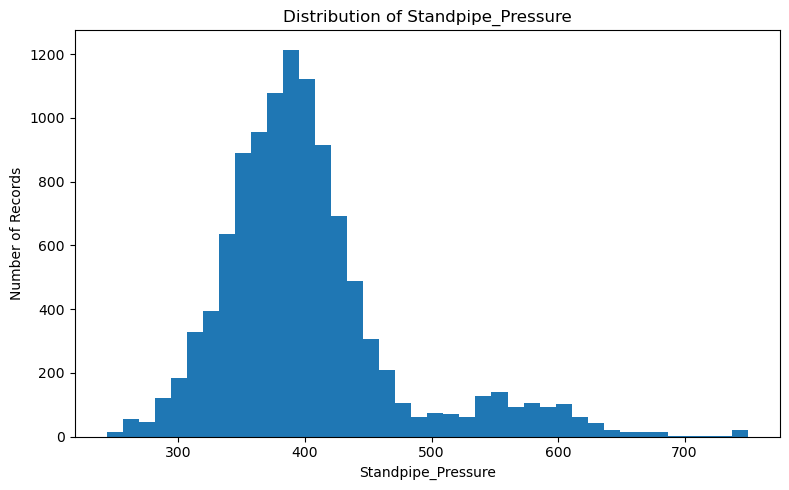

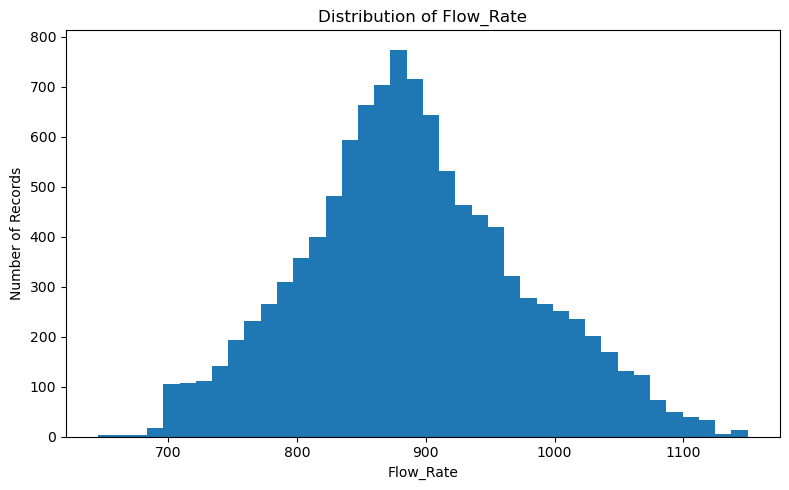

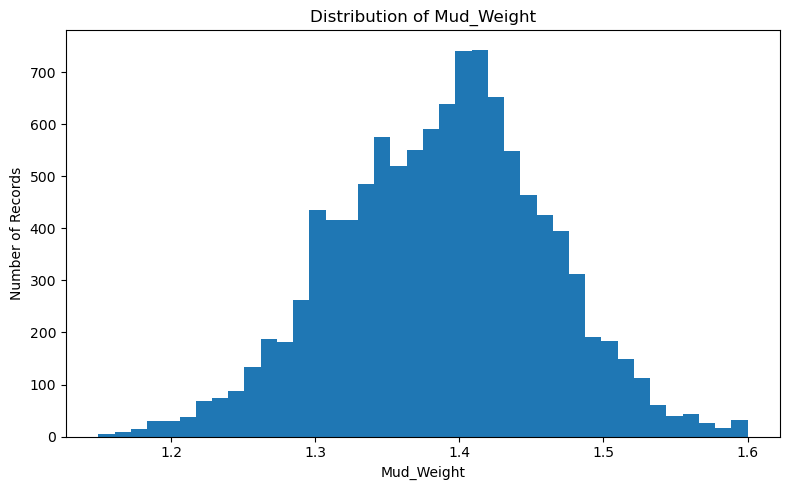

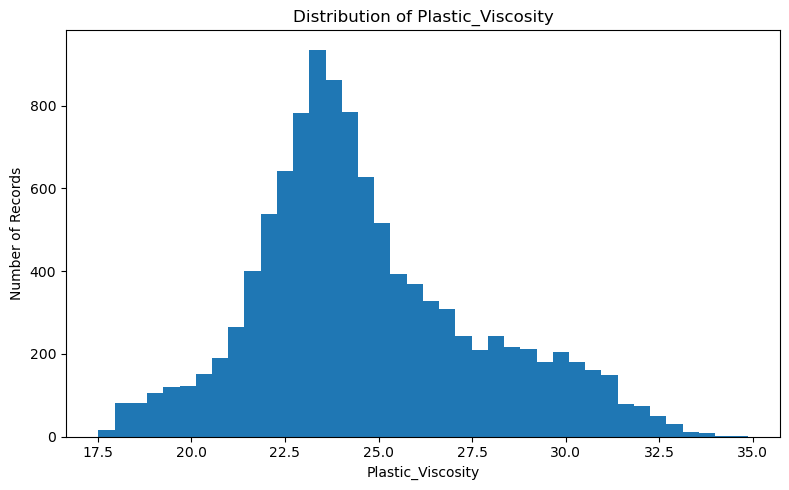

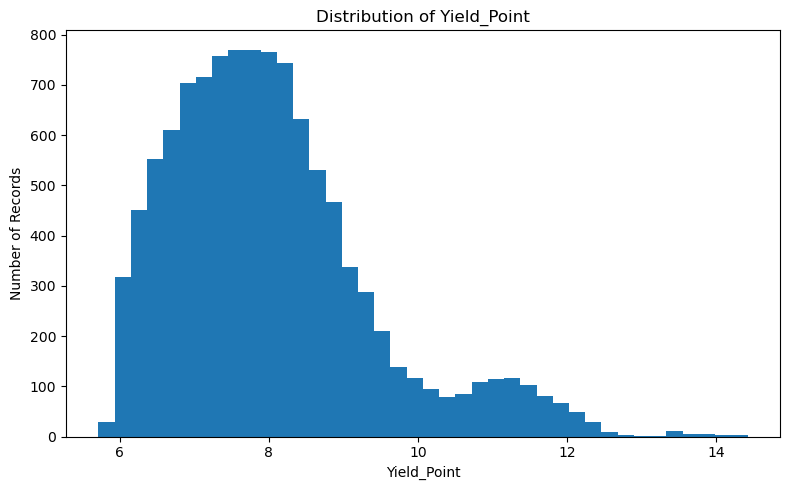

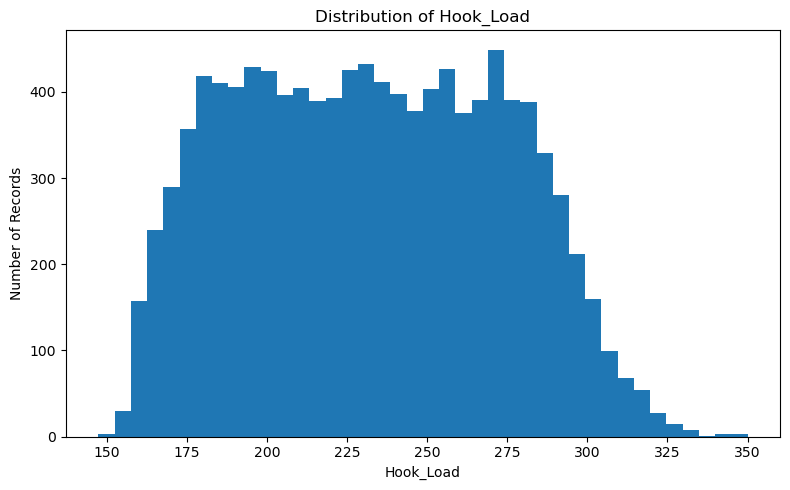

In [51]:
# Before looking for risk patterns, we need to understand the
# normal operating range of the drilling parameters.

for column in drilling_parameters:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[column].dropna(),
        bins=40
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")

    plt.tight_layout()
    plt.show()

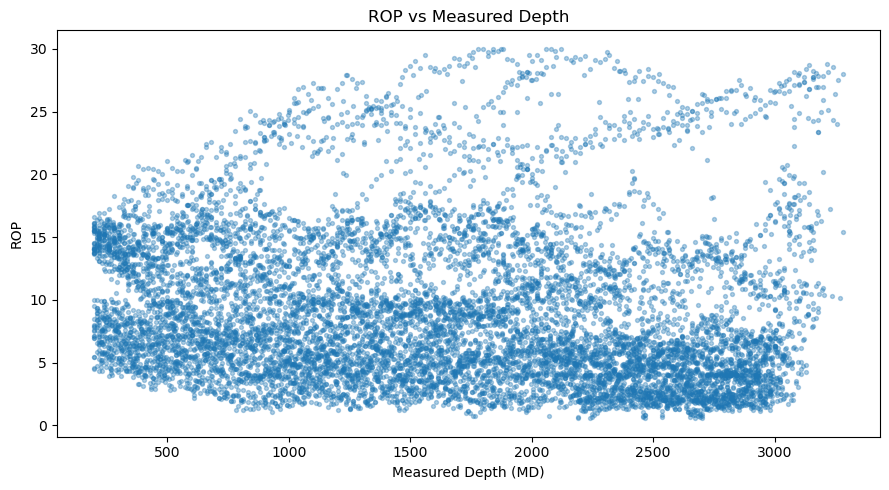

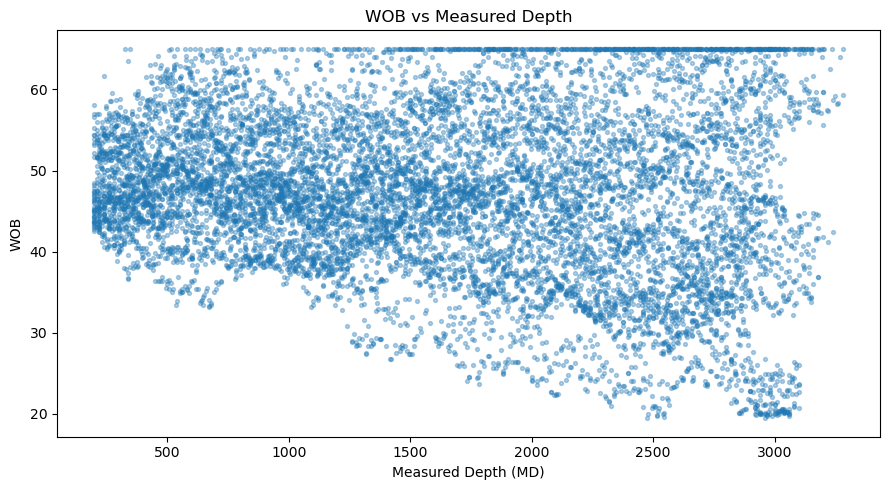

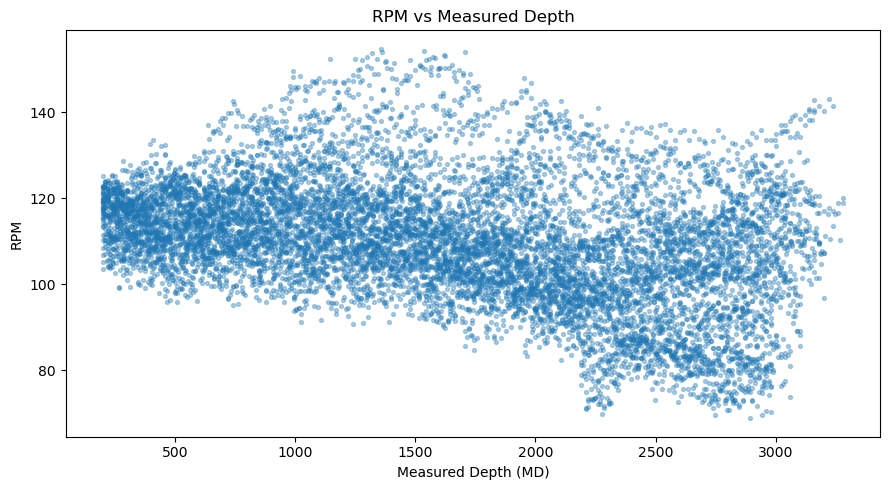

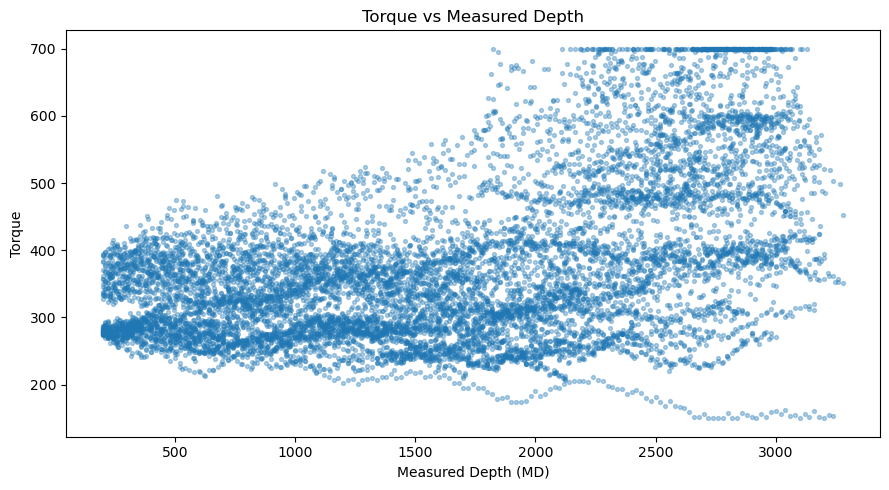

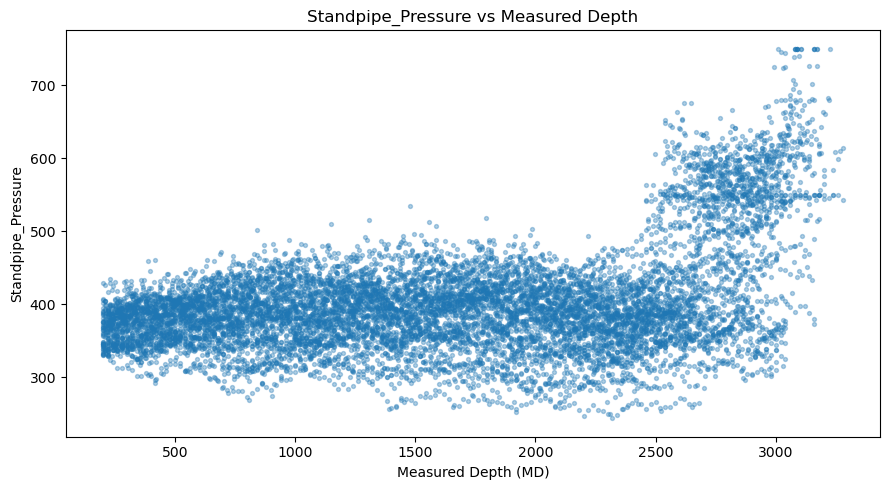

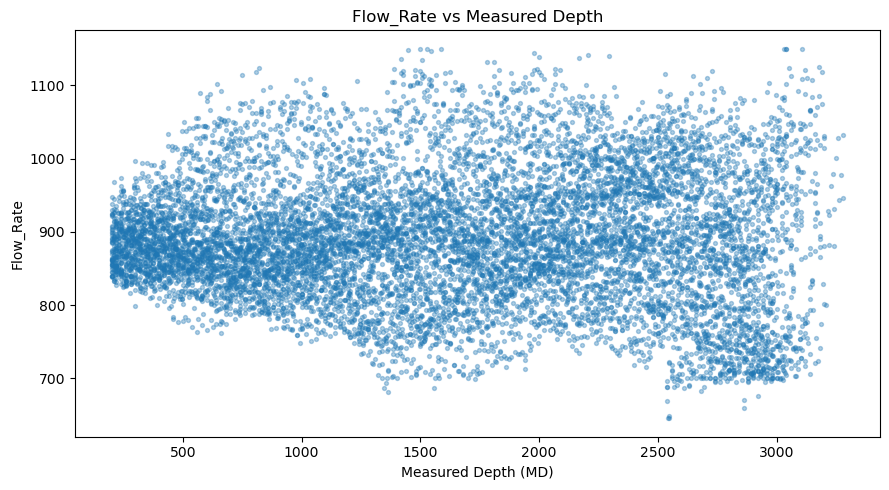

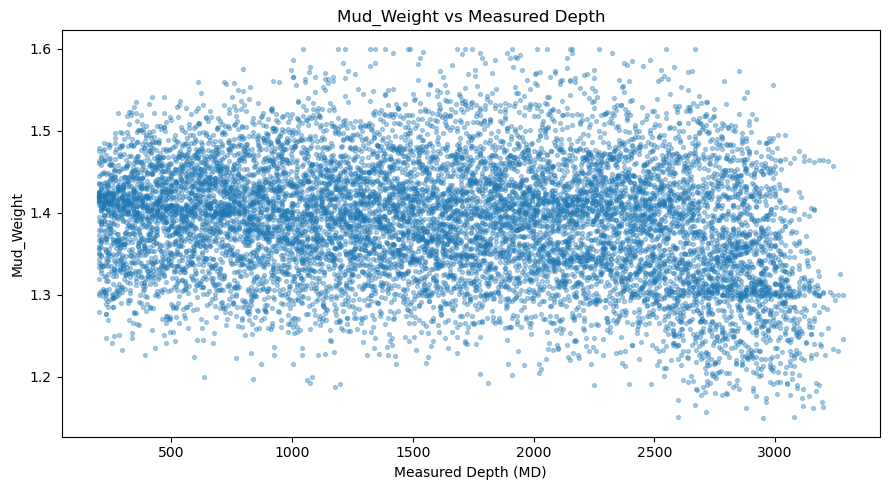

In [50]:
# Drilling behaviour changes as the bit moves deeper.
# These plots help identify depth-dependent operating patterns.

depth_parameters = [
    "ROP",
    "WOB",
    "RPM",
    "Torque",
    "Standpipe_Pressure",
    "Flow_Rate",
    "Mud_Weight"
]

for column in depth_parameters:

    plt.figure(figsize=(9, 5))

    plt.scatter(
        df["Depth_MD"],
        df[column],
        s=8,
        alpha=0.35
    )

    plt.title(f"{column} vs Measured Depth")
    plt.xlabel("Measured Depth (MD)")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()


FORMATION DISTRIBUTION :


,Records
Formation,
Shale_A,4546
Limestone_B,3033
Shale_B,2221
Alluvium_Top,740
Sandstone_C,336


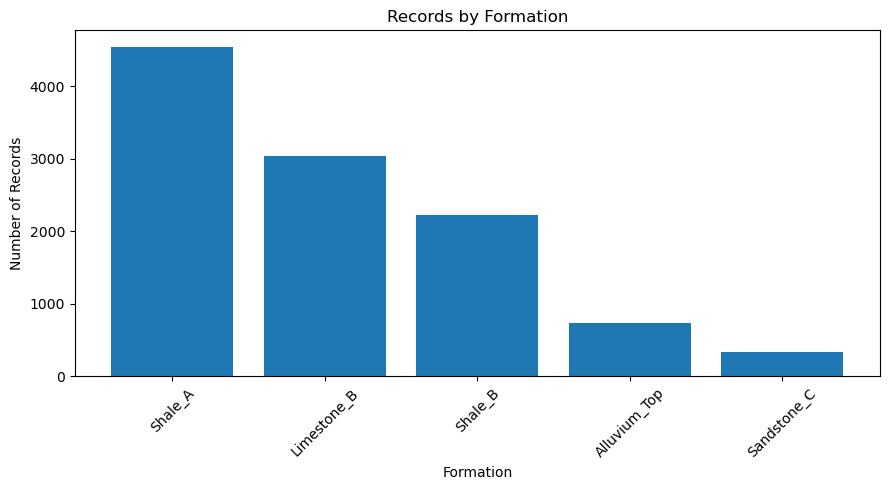

In [22]:
# Plot for FORMATION DISTRIBUTION

formation_counts = df["Formation"].value_counts()
print("FORMATION DISTRIBUTION :")
display(formation_counts.to_frame("Records"))
plt.figure(figsize=(9, 5))
plt.bar(
    formation_counts.index.astype(str),
    formation_counts.values
)

plt.title("Records by Formation")
plt.xlabel("Formation")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Different formations can produce different drilling behaviour.
# This is useful when comparing the current well with historical
# wells drilled through similar formations.

formation_summary = (
    df.groupby("Formation")[drilling_parameters]
    .mean()
)
print("AVERAGE DRILLING PARAMETERS BY FORMATION :")
display(formation_summary.round(2))

AVERAGE DRILLING PARAMETERS BY FORMATION :


,ROP,WOB,RPM,Torque,Standpipe_Pressure,Flow_Rate,Mud_Weight,Plastic_Viscosity,Yield_Point,Hook_Load
Formation,,,,,,,,,,
Alluvium_Top,10.79,48.35,115.22,323.24,371.18,884.15,1.39,23.98,8.17,169.33
Limestone_B,8.88,46.43,106.79,370.22,382.25,902.64,1.40,25.26,7.95,249.88
Sandstone_C,12.49,45.12,111.59,473.70,563.77,897.40,1.31,23.80,7.63,298.94
Shale_A,9.51,48.31,115.30,326.58,384.88,889.27,1.40,24.46,8.00,201.95
Shale_B,6.59,44.81,100.96,482.36,449.97,875.75,1.36,24.69,8.23,281.12


In [26]:
balance = []

for label in risk_labels:

    normal = (df[label] == 0).sum()
    risk = (df[label] == 1).sum()

    balance.append({
        "Risk": label.replace("_Label", ""),
        "Normal": normal,
        "Risk": risk,
        "Normal_%": round(normal / len(df) * 100, 2),
        "Risk_%": round(risk / len(df) * 100, 2)
    })

balance_df = pd.DataFrame(balance)

print("RISK CLASS BALANCE :")

display(balance_df)

RISK CLASS BALANCE :


,Risk,Normal,Normal_%,Risk_%
0,4242,6634,61.0,39.0
1,4568,6308,58.0,42.0
2,4133,6743,62.0,38.0
3,4459,6417,59.0,41.0
4,4133,6743,62.0,38.0
5,4350,6526,60.0,40.0


In [28]:
# If drilling parameters behave differently during risk events,
# they can become useful predictive features.

for label in risk_labels:
    comparison = (
        df.groupby(label)[drilling_parameters]
        .mean()
        .T
    )
    comparison.columns = ["Normal", "Risk"]
    print(
        f"{label.replace('_Label', '').upper()} "
        "— NORMAL VS RISK"
    )
    display(comparison.round(2))

MUD_LOSS — NORMAL VS RISK


,Normal,Risk
ROP,7.14,11.70
WOB,45.99,48.50
RPM,109.33,110.73
Torque,389.92,351.37
Standpipe_Pressure,417.65,377.60
Flow_Rate,859.97,937.31
Mud_Weight,1.40,1.38
Plastic_Viscosity,24.99,24.18
Yield_Point,8.13,7.89
Hook_Load,236.26,226.00


STUCK_PIPE — NORMAL VS RISK


,Normal,Risk
ROP,11.28,5.66
WOB,45.72,48.70
RPM,114.04,104.12
Torque,315.72,456.57
Standpipe_Pressure,385.26,425.19
Flow_Rate,883.18,899.75
Mud_Weight,1.40,1.37
Plastic_Viscosity,24.26,25.25
Yield_Point,8.09,7.96
Hook_Load,217.85,252.16


OVERPRESSURE — NORMAL VS RISK


...

,Normal,Risk
ROP,11.25,5.56
WOB,45.93,48.47
RPM,113.91,104.07
Torque,315.87,459.80
Standpipe_Pressure,385.56,425.74
Flow_Rate,884.89,897.69
Mud_Weight,1.40,1.38
Plastic_Viscosity,24.32,25.18
Yield_Point,8.08,7.96
Hook_Load,218.66,251.84


CEMENTING_ISSUE — NORMAL VS RISK


,Normal,Risk
ROP,9.37,8.18
WOB,47.58,45.98
RPM,113.13,104.56
Torque,343.33,426.35
Standpipe_Pressure,392.08,418.27
Flow_Rate,886.21,896.55
Mud_Weight,1.40,1.37
Plastic_Viscosity,24.46,25.03
Yield_Point,8.01,8.07
Hook_Load,211.93,265.43


KICK — NORMAL VS RISK


,Normal,Risk
ROP,9.05,8.73
WOB,46.57,47.58
RPM,112.88,105.38
Torque,352.29,408.78
Standpipe_Pressure,396.08,410.97
Flow_Rate,868.09,923.21
Mud_Weight,1.41,1.36
Plastic_Viscosity,24.72,24.61
Yield_Point,8.09,7.96
Hook_Load,217.38,254.58


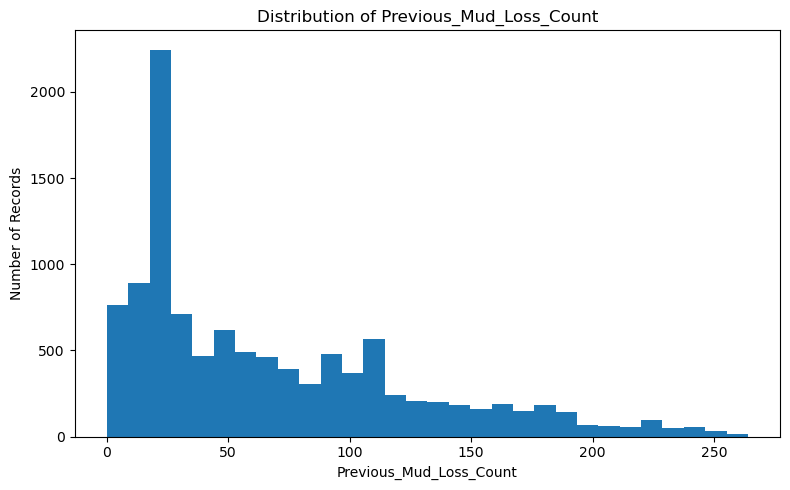

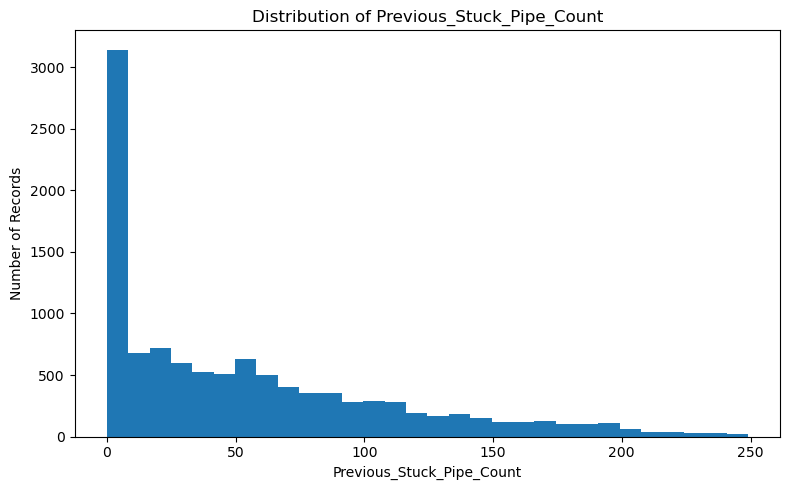

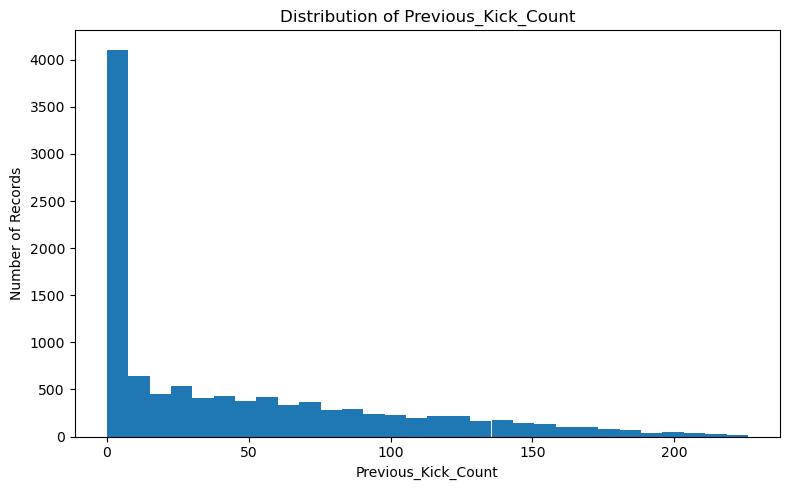

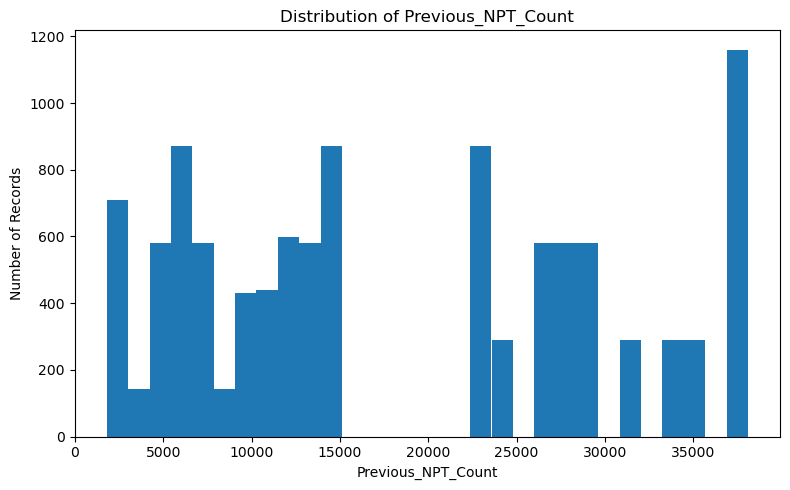

In [30]:
#  HISTORICAL EVENT COUNTS
for column in historical_features:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column],bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.tight_layout()
    plt.show()

In [39]:
# More than one risk can exist under the same drilling condition.
# This is important for NWIS because the system may need to warn
# engineers about multiple possible problems.

risk_cooccurrence = df[risk_labels].corr()
print("RISK CO-OCCURRENCE :")
display(risk_cooccurrence.round(3))

RISK CO-OCCURRENCE :


,Mud_Loss_Label,Stuck_Pipe_Label,Overpressure_Label,Torque_Spike_Label,Cementing_Issue_Label
Mud_Loss_Label,1.000,-0.096,-0.038,-0.125,0.003
Stuck_Pipe_Label,-0.096,1.000,0.248,0.614,0.247
Overpressure_Label,-0.038,0.248,1.000,0.225,0.467
Torque_Spike_Label,-0.125,0.614,0.225,1.000,0.232
Cementing_Issue_Label,0.003,0.247,0.467,0.232,1.000


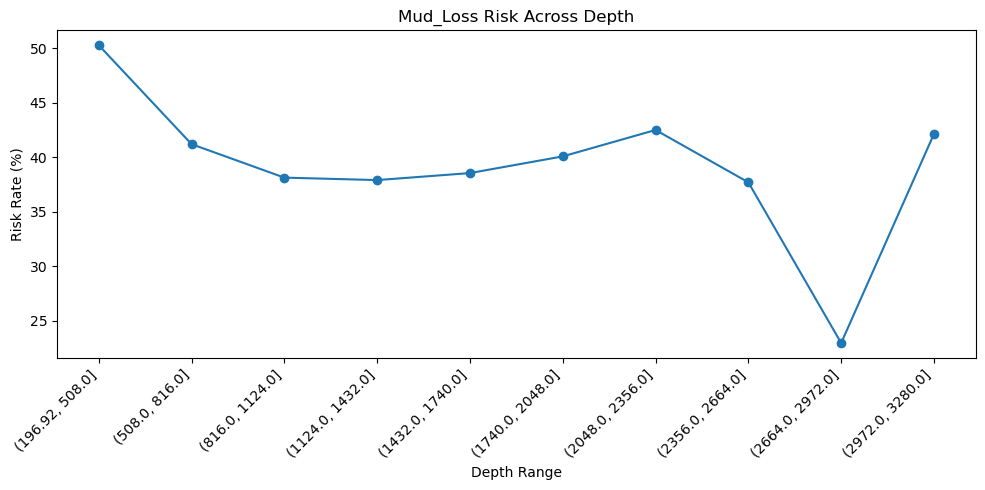

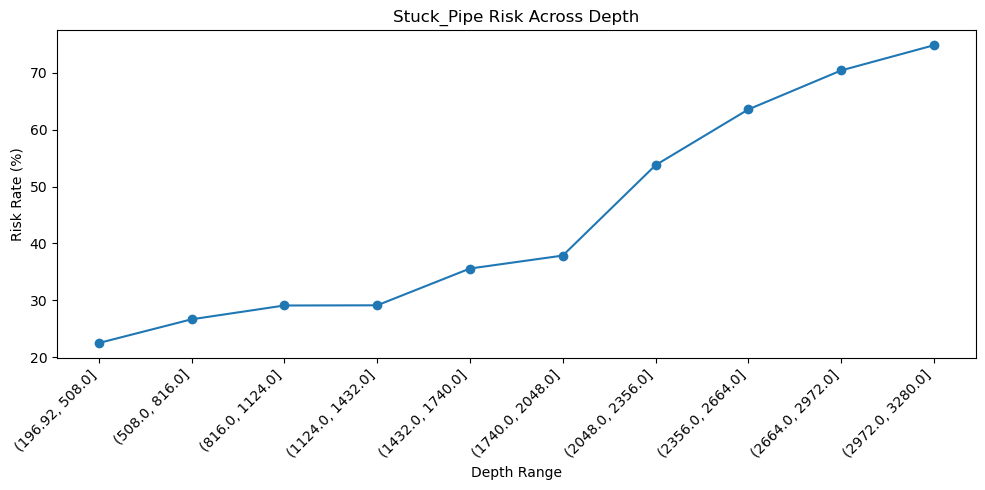

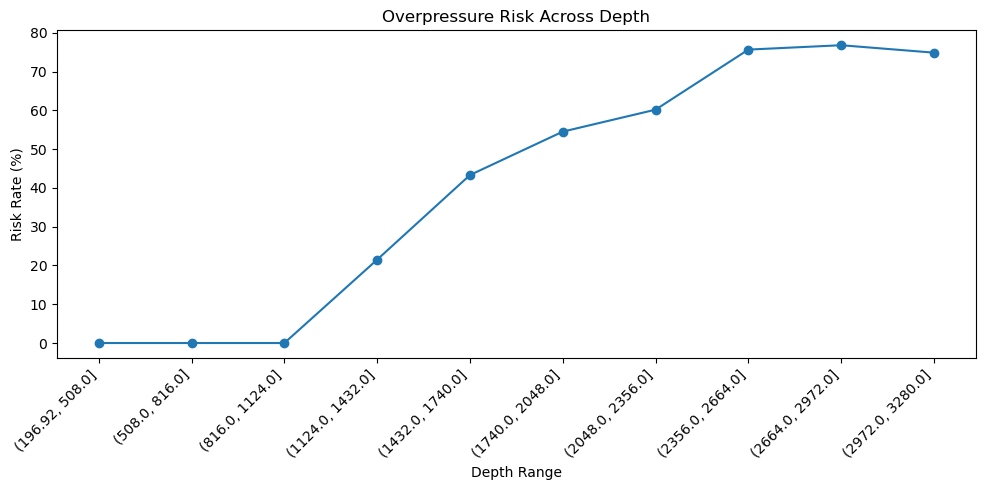

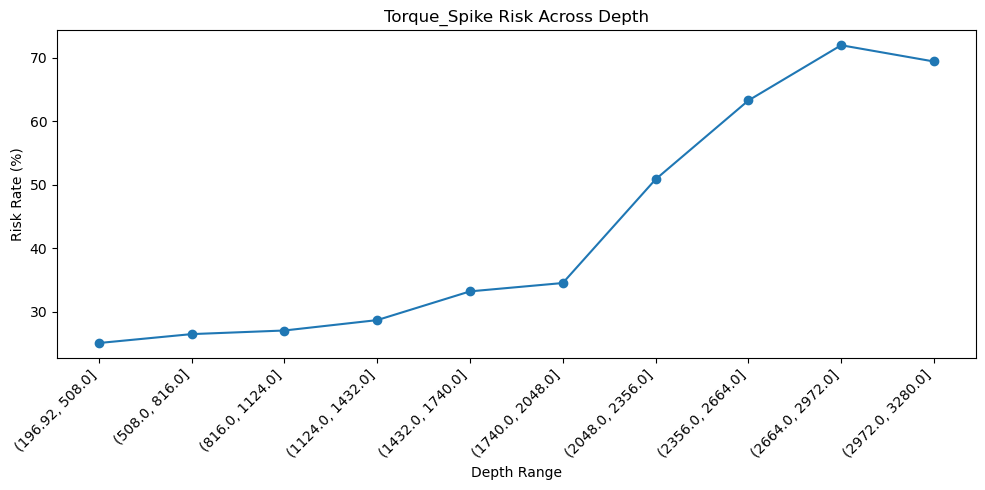

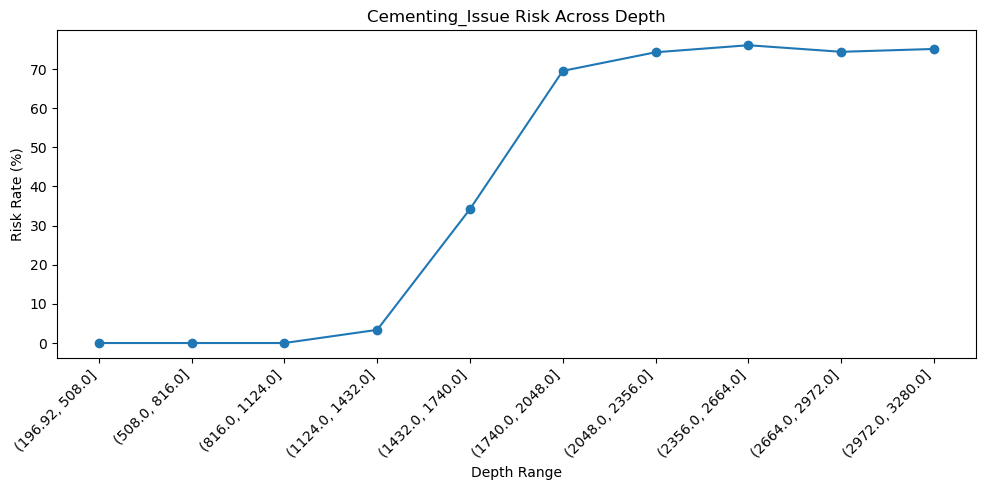

In [49]:
# Real-time drilling risk is often depth dependent.
# This shows whether risk frequency changes as drilling progresses.

depth_bins = pd.cut(df["Depth_MD"],bins=10)
for label in risk_labels:
    depth_risk = (
        df.groupby(depth_bins,observed=True)[label].mean() * 100)
    plt.figure(figsize=(10, 5))
    plt.plot(
        range(len(depth_risk)),
        depth_risk.values,
        marker="o"
    )
    plt.xticks(
        range(len(depth_risk)),
        [
            str(interval)
            for interval in depth_risk.index
        ],
        rotation=45,
        ha="right"
    )
    plt.title(
        f"{label.replace('_Label', '')} "
        "Risk Across Depth"
    )
    plt.xlabel("Depth Range")
    plt.ylabel("Risk Rate (%)")
    plt.tight_layout()
    plt.show()

In [44]:
# OUTLIER CHECK

outlier_results = []
for column in drilling_parameters:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()
    outlier_results.append({
        "Feature": column,
        "Lower_Bound": round(lower_bound, 3),
        "Upper_Bound": round(upper_bound, 3),
        "Potential_Outliers": int(outliers),
        "Outlier_%": round(
            outliers / len(df) * 100,
            2
        )
    })
outlier_df = pd.DataFrame(outlier_results)
print("OUTLIER CHECK :")
display(outlier_df)

OUTLIER CHECK :


,Feature,Lower_Bound,Upper_Bound,Potential_Outliers,Outlier_%
0,ROP,-7.609,24.597,297,2.73
1,WOB,20.541,74.004,55,0.51
2,RPM,75.884,144.445,220,2.02
3,Torque,86.605,617.501,570,5.24
4,Standpipe_Pressure,258.959,523.552,933,8.58
5,Flow_Rate,667.720,1112.358,55,0.51
6,Mud_Weight,1.189,1.585,71,0.65
7,Plastic_Viscosity,17.196,31.928,156,1.43
8,Yield_Point,4.578,11.129,509,4.68
9,Hook_Load,95.458,368.485,0,0.00


In [48]:
# EDA CONCLUSION FOR ML PREPARATION
print("\n" + "*" * 70)
print("EDA COMPLETED")
print("*" * 70)
print("""
Key areas examined:

1. Data quality and missing values
2. Duplicate records
3. Well and depth coverage
4. Drilling parameter distributions
5. Formation-wise drilling behaviour
6. Risk class balance
7. Drilling behaviour during risk events
8. Feature-to-risk correlations
9. Risk behaviour across depth
10. Multiple-risk co-occurrence
11. Potential outliers

The dataset is now ready for the next stage:
feature preprocessing → train/test split → ML model training → risk probability.
""")


**********************************************************************
EDA COMPLETED
**********************************************************************

Key areas examined:

1. Data quality and missing values
2. Duplicate records
3. Well and depth coverage
4. Drilling parameter distributions
5. Formation-wise drilling behaviour
6. Risk class balance
7. Drilling behaviour during risk events
8. Feature-to-risk correlations
9. Risk behaviour across depth
10. Multiple-risk co-occurrence
11. Potential outliers

The dataset is now ready for the next stage:
feature preprocessing → train/test split → ML model training →risk probability.

